## README:

* Cells labeled with '## ----- CONFIG ----- ##' contain parameters that need to be set manually 

In [1]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from functools import reduce
from dotenv import load_dotenv

In [2]:
# add project root to path
root_path = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.append(root_path)

## Load env variables

In [3]:
load_dotenv(r'../.env')

DATA_DIR = os.getenv('DATA_DIR')

## Global config

In [4]:
## ----- CONFIG ----- ##
WRITE_MODE = 'w' # 'x': do not overwrite

## Examine and clean raw data

### FRED

In [5]:
from data_processing.fred_api import processing_steps as proc

In [6]:
## ----- CONFIG ----- ##
FRED_VERSION = '001'

# specify frequencies of each series
SERIES_FREQ = {
    'VIXCLS': 'D',
    'DFF': 'D',
    'T10Y2Y': 'D',
    'REAINTRATREARAT10Y': 'MS',
    'BAMLH0A0HYM2': 'D',
    'CPIAUCSL': 'MS',
    'ICSA': 'W-SAT',
    'PPIACO': 'MS',
    'USSTHPI': 'QS'
}

In [7]:
# get FRED data files
pattern = os.path.join(DATA_DIR, 'FRED', f'*_{FRED_VERSION}.csv')
fred_files = glob.glob(pattern)
len(fred_files)

9

===== Processing BAMLH0A0HYM2 =====
	Step: format | Rows: 7646 | NA count: 92 | NA %: 1.2
	Step: expand dates | Rows: 10566 | NA count: 3012 | NA %: 28.51
	Step: impute | Rows: 7646 | NA count: 0 | NA %: 0.0
===== Processing CPIAUCSL =====
	Step: format | Rows: 609 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 609 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 609 | NA count: 0 | NA %: 0.0
===== Processing DFF =====
	Step: format | Rows: 18601 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 18601 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 18601 | NA count: 0 | NA %: 0.0
===== Processing ICSA =====
	Step: format | Rows: 2657 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 2657 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 2657 | NA count: 0 | NA %: 0.0
===== Processing PPIACO =====
	Step: format | Rows: 609 | NA count: 0 | NA %: 0.0
	Step: expand dates | Rows: 609 | NA count: 0 | NA %: 0.0
	Step: impute | Rows: 609 | NA count: 0 | NA %: 0.0
===== Processing R

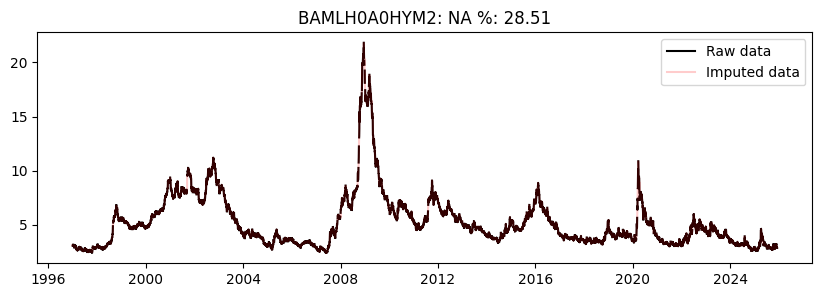

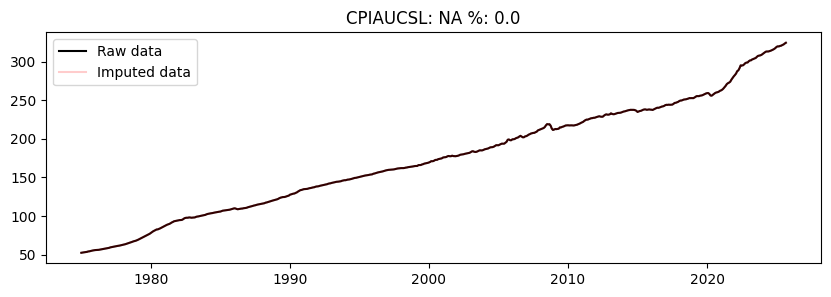

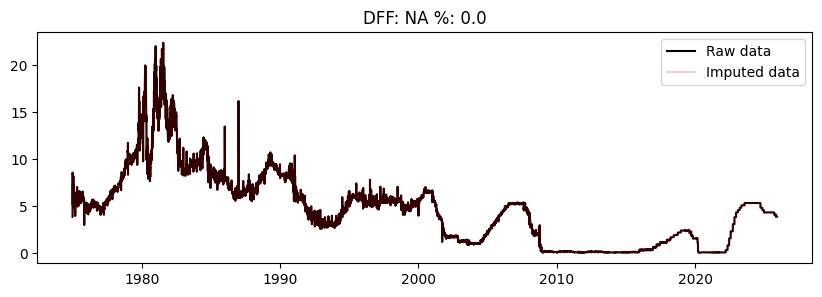

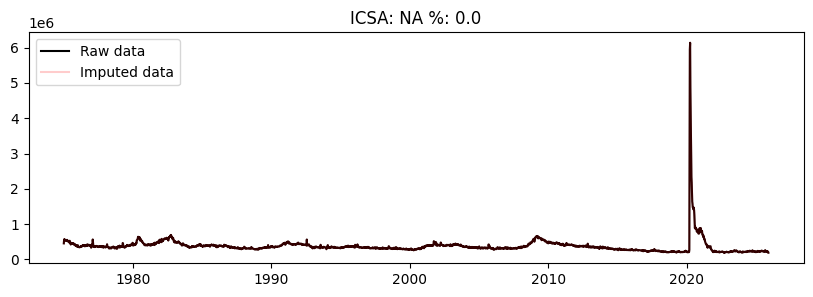

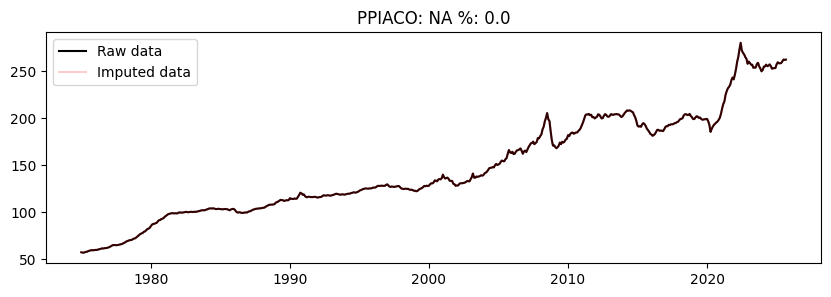

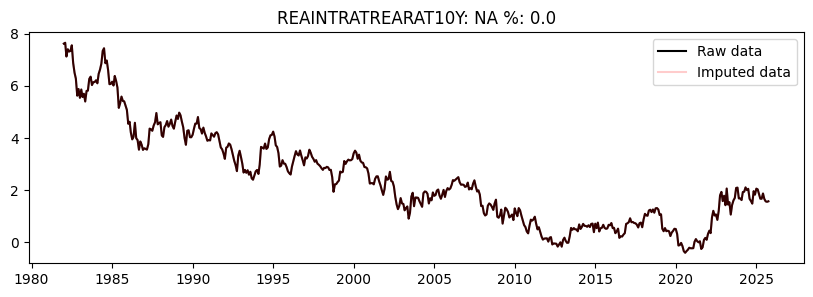

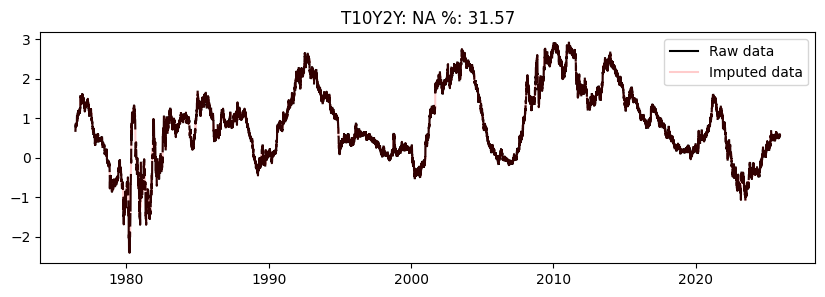

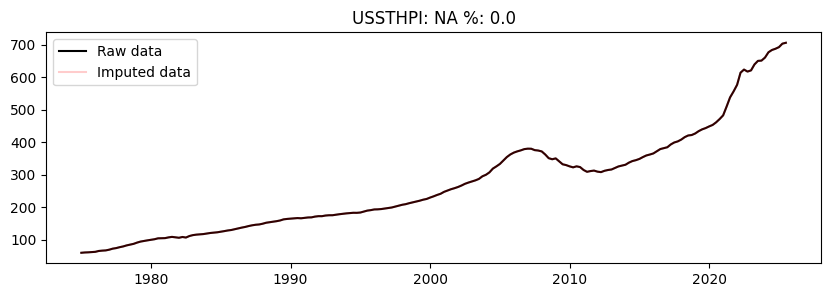

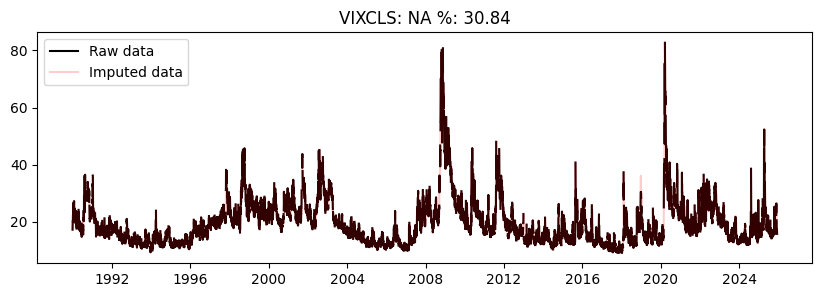

In [8]:
# read data
fred_data = dict()

for file in fred_files:
    series_id = os.path.basename(file).split('_')[0]
    print(f'===== Processing {series_id} =====')

    df = pd.read_csv(file)

    # apply pre-processing steps
    df = proc.format_raw_series(series_id, df)
    df_expanded = proc.expand_full_dates(df, freq=SERIES_FREQ[series_id])
    df_imputed = proc.impute_missing_data(series_id, df)

    # plot original data + imputed segments
    na_perc = round(df_expanded.isna().mean().values[0]*100, 2)
    fig, ax = plt.subplots(figsize=(10,3))
    ax.set_title(f"{series_id}: NA %: {na_perc}")
    ax.plot(df_expanded, label='Raw data', c='black')
    ax.plot(df_imputed, label='Imputed data', c='red', alpha=0.2)
    ax.legend()

    # store processed data
    fred_data[series_id] = df_imputed

In [9]:
# join all FRED series by date index
fred_df = reduce(lambda left, right: left.join(right, how='outer'), fred_data.values())
fred_df = fred_df.sort_index()
fred_df.shape

(18602, 9)

In [10]:
# resample to daily frequency by filling forward to avoid data leakage
fred_df = fred_df.ffill()

In [11]:
na_df = fred_df.isna()

# check NA % in each column
print(na_df.shape)
na_df.mean(axis=0)

(18602, 9)


BAMLH0A0HYM2          0.431943
CPIAUCSL              0.000000
DFF                   0.000000
ICSA                  0.000161
PPIACO                0.000000
REAINTRATREARAT10Y    0.137458
T10Y2Y                0.027793
USSTHPI               0.000000
VIXCLS                0.294592
dtype: float64

In [12]:
# get idx of first datapoint for each ticker/price
first_datapoint_idx = (na_df.cumprod(axis=0).sum(axis=0)).clip(lower=0)

# get dates of those idx
first_datapoint_date = fred_df.index[first_datapoint_idx]

# check which ticker has the least data
first_datapoint_df = pd.DataFrame({
    'first_data_date': first_datapoint_date,
    'series_id': fred_df.columns
})
first_datapoint_df.sort_values(['first_data_date', 'series_id'], ascending=False)

,first_data_date,series_id
0,1996-12-31,BAMLH0A0HYM2
8,1990-01-02,VIXCLS
5,1982-01-01,REAINTRATREARAT10Y
6,1976-06-01,T10Y2Y
3,1975-01-04,ICSA
7,1975-01-01,USSTHPI
4,1975-01-01,PPIACO
2,1975-01-01,DFF
1,1975-01-01,CPIAUCSL


In [13]:
## ----- CONFIG ----- ##
# choose a start date
START_DATE = '1996-12-31'

# choose series to exclude
EXCLUDE_IDS = []

In [14]:
# subset columns
cols_filter = ~fred_df.columns.isin(EXCLUDE_IDS)

# check NAs of subset
print('NAs detected:', na_df.loc[START_DATE:, cols_filter].any().any())
print('Data points per ticker:', fred_df.loc[START_DATE:, cols_filter].shape[0])

NAs detected: False
Data points per ticker: 10567


### YFINANCE

In [15]:
## ----- CONFIG ----- ##
YF_VERSION = '001'

In [16]:
# get raw data
input_file = os.path.join(DATA_DIR, 'YFINANCE', f'prices_{YF_VERSION}.csv')
prices_df = pd.read_csv(input_file, header=[0,1], low_memory=False)

In [17]:
# check NAs in dates
dt_index = pd.to_datetime(prices_df['Date'].iloc[:,0])
dt_index.name = 'date'

print('NAs detected:', any(dt_index.isna()))
print('Unique dates:', dt_index.nunique())
print('Date range:', dt_index.min(), dt_index.max())

NAs detected: False
Unique dates: 12840
Date range: 1975-01-02 00:00:00 2025-12-04 00:00:00


In [18]:
# set date index
prices_df = (
    prices_df
    .set_index(dt_index)
    .drop('Date', level=0, axis=1)
)

In [19]:
# check df attributes
print(prices_df.shape)

price_types = sorted(set(prices_df.columns.get_level_values(0)))
print(price_types)

tics = sorted(set(prices_df.columns.get_level_values(1)))
print(tics)

# sort by column levels
prices_df = prices_df.sort_index(axis=1, level=[0, 1])

(12840, 50)
['Close', 'High', 'Low', 'Open', 'Volume']
['AAPL', 'AMZN', 'GOOG', 'JPM', 'MSFT', 'NVDA', 'PG', 'SPY', 'UNH', 'XOM']


Text(0.5, 1.0, 'Counts of NAs for each date')

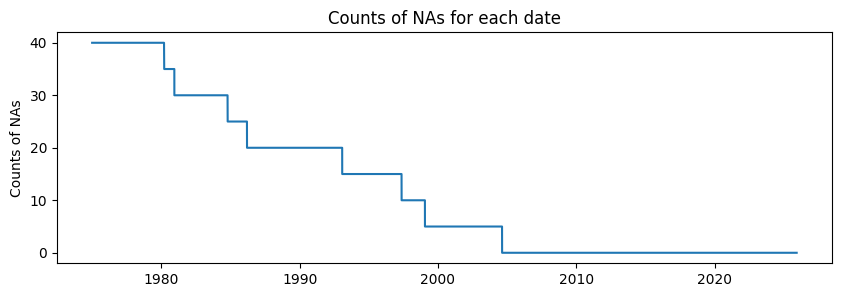

In [20]:
# count NAs in prices
na_df = prices_df.isna()
na_count = na_df.sum(axis=1)

fig, ax = plt.subplots(figsize=(10,3))
ax.plot(na_count)
ax.set_ylabel("Counts of NAs")
ax.set_title('Counts of NAs for each date')

In [21]:
# get idx of first datapoint for each ticker/price
first_datapoint_idx = (na_df[price_types[0]].cumprod(axis=0).sum(axis=0)).clip(lower=0)

# get dates of those idx
first_datapoint_date = prices_df.index[first_datapoint_idx]

# check which ticker has the least data
first_datapoint_df = pd.DataFrame({
    'first_data_date': first_datapoint_date,
    'price/ticker': tics
})
first_datapoint_df.sort_values(['first_data_date', 'price/ticker'], ascending=False)

,first_data_date,price/ticker
2,2004-08-19,GOOG
5,1999-01-22,NVDA
1,1997-05-15,AMZN
7,1993-01-29,SPY
4,1986-03-13,MSFT
8,1984-10-17,UNH
0,1980-12-12,AAPL
3,1980-03-17,JPM
9,1975-01-02,XOM
6,1975-01-02,PG


In [22]:
## ----- CONFIG ----- ##
# choose a start date
START_DATE = '1999-01-22'

# choose tickers to exclude
EXCLUDE_TICS = ['GOOG']

In [23]:
# subset columns
cols_filter = ~prices_df.columns.get_level_values(1).isin(EXCLUDE_TICS)

# check NAs of subset
print('NAs detected:', na_df.loc[START_DATE:, cols_filter].any().any())
print('Data points per ticker:', prices_df.loc[START_DATE:, cols_filter].shape[0])

NAs detected: False
Data points per ticker: 6760


In [24]:
# get no-NA subset
sub_prices_df = prices_df.loc[START_DATE:, cols_filter]

# restructure prices DF
sub_prices_df = (
    sub_prices_df
    .stack(level=1, future_stack=True)
    .reset_index(level=1)
    .rename({'level_1': 'tic'}, axis=1)
)

# rename columns
sub_prices_df.columns = [col.lower() for col in sub_prices_df.columns]

print(sub_prices_df.shape)
sub_prices_df.head()

(60840, 6)


,tic,close,high,low,open,volume
date,,,,,,
1999-01-22,AAPL,0.290538,0.296162,0.277886,0.282572,3.457664e+08
1999-01-22,AMZN,3.075000,3.146875,2.468750,2.487500,8.753160e+08
1999-01-22,JPM,22.352217,23.168559,22.274469,22.974191,7.715700e+06
1999-01-22,MSFT,23.861563,24.470033,23.708849,23.766116,8.216000e+07
1999-01-22,NVDA,0.037605,0.044767,0.035575,0.040111,2.714688e+09


## Combine data

In [25]:
joined_df = (
    sub_prices_df
    .join(fred_df, how='inner')
    .reset_index()
    .rename({'index': 'date'}, axis=1)
)
joined_na_df = joined_df.isna()

# check NAs of subset
print('NAs detected:', joined_na_df.any().any())
print('Data points per ticker:', joined_df.shape[0] / len(tics))

NAs detected: False
Data points per ticker: 6084.0


In [26]:
joined_df.head()

,date,tic,close,high,low,open,volume,BAMLH0A0HYM2,CPIAUCSL,DFF,ICSA,PPIACO,REAINTRATREARAT10Y,T10Y2Y,USSTHPI,VIXCLS
0,1999-01-22,AAPL,0.290538,0.296162,0.277886,0.282572,3.457664e+08,5.59,164.7,4.62,339000.0,122.9,2.308152,0.05,217.23,31.95
1,1999-01-22,AMZN,3.075000,3.146875,2.468750,2.487500,8.753160e+08,5.59,164.7,4.62,339000.0,122.9,2.308152,0.05,217.23,31.95
2,1999-01-22,JPM,22.352217,23.168559,22.274469,22.974191,7.715700e+06,5.59,164.7,4.62,339000.0,122.9,2.308152,0.05,217.23,31.95
3,1999-01-22,MSFT,23.861563,24.470033,23.708849,23.766116,8.216000e+07,5.59,164.7,4.62,339000.0,122.9,2.308152,0.05,217.23,31.95
4,1999-01-22,NVDA,0.037605,0.044767,0.035575,0.040111,2.714688e+09,5.59,164.7,4.62,339000.0,122.9,2.308152,0.05,217.23,31.95


In [27]:
# export data
out_path = os.path.join(DATA_DIR, 'preprocessed.csv')
joined_df.to_csv(out_path, index=False, mode=WRITE_MODE)